In [17]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [18]:
df = pd.read_csv("Data/M3_HW2_Dataset.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,1/3/23,1/7/23,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,1/4/23,1/8/23,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,1/4/23,1/8/23,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,1/4/23,1/8/23,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,1/5/23,1/12/23,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


## Part 1: Establish a Baseline and Explore the Dataset

Using head and other functions to be able to determing what the data means and what it is 

In [19]:
df.shape

(10197, 21)

In [20]:
df.info

<bound method DataFrame.info of        Row ID        Order ID Order Date Ship Date       Ship Mode  \
0           1  US-2023-103800     1/3/23    1/7/23  Standard Class   
1           2  US-2023-112326     1/4/23    1/8/23  Standard Class   
2           3  US-2023-112326     1/4/23    1/8/23  Standard Class   
3           4  US-2023-112326     1/4/23    1/8/23  Standard Class   
4           5  US-2023-141817     1/5/23   1/12/23  Standard Class   
...       ...             ...        ...       ...             ...   
10192   10193  US-2026-143259   12/30/26    1/3/27  Standard Class   
10193   10194  CA-2026-143500   12/30/26    1/3/27  Standard Class   
10194    7459  US-2026-152366    4/21/26   4/25/26    Second Class   
10195    6607  US-2025-162187   12/11/25  12/11/25        Same Day   
10196    6871  US-2026-138779    1/14/26   1/15/26     First Class   

      Customer ID      Customer Name      Segment Country/Region  \
0        DP-13000      Darren Powers     Consumer  United S

In [21]:
df.describe()

,Row ID,Sales,Discount,Profit
count,10197.000000,10194.000000,10197.000000,10194.000000
mean,5098.053545,252.749867,0.155579,23.708219
std,2942.648952,2550.323407,0.206616,547.329611
min,1.000000,0.444000,0.000000,-50000.000000
25%,2550.000000,17.225000,0.000000,1.751550
50%,5099.000000,53.930000,0.200000,8.685500
75%,7645.000000,209.500000,0.200000,29.282175
max,10194.000000,250000.000000,1.250000,8399.976000


In [22]:
df.nunique()

Row ID            10194
Order ID           5111
Order Date         1244
Ship Date          1338
Ship Mode             4
Customer ID         804
Customer Name       800
Segment               3
Country/Region        2
City                542
State/Province       63
Postal Code         654
Region                4
Product ID         1862
Category              6
Sub-Category         17
Product Name       1849
Sales              5836
Quantity             16
Discount             13
Profit             7333
dtype: int64

In [23]:
df.columns.to_list()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country/Region',
 'City',
 'State/Province',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

In [24]:
df.dtypes

Row ID              int64
Order ID           object
Order Date         object
Ship Date          object
Ship Mode          object
Customer ID        object
Customer Name      object
Segment            object
Country/Region     object
City               object
State/Province     object
Postal Code        object
Region             object
Product ID         object
Category           object
Sub-Category       object
Product Name       object
Sales             float64
Quantity           object
Discount          float64
Profit            float64
dtype: object

In [25]:
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
10192,10193,US-2026-143259,12/30/26,1/3/27,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,...,10009,East,TEC-PH-10004774,Technology,Phones,Gear Head AU3700S Headset,90.930,7,0.0,2.7279
10193,10194,CA-2026-143500,12/30/26,1/3/27,Standard Class,HO-15230,Harry Olson,Consumer,Canada,Charlottetown,...,C0A,East,OFF-BI-10004040,Office Supplies,Binders,Wilson Jones Impact Binders,3.024,3,0.2,-0.6048
10194,7459,US-2026-152366,4/21/26,4/25/26,Second Class,SJ-20500,Shirley Jackson,Consumer,United States,Houston,...,77036,Central,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",97.264,4,0.8,-243.1600
10195,6607,US-2025-162187,12/11/25,12/11/25,Same Day,NS-18640,Noel Staavos,Corporate,United States,Columbus,...,43229,East,FUR-TA-10003008,Furniture,Tables,"Lesro Round Back Collection Coffee Table, End ...",328.590,3,0.4,-147.8655
10196,6871,US-2026-138779,1/14/26,1/15/26,First Class,RB-19570,Rob Beeghly,Consumer,United States,Jacksonville,...,28540,South,TEC-PH-10003655,Technology,Phones,Sannysis Cute Owl Design Soft Skin Case Cover ...,7.920,5,0.2,0.6930


This data set has 10197 rows with 21 columns. Most of the variables within this dataset are categorical, or an object type. There are 4 columns that are not an object type. The row index is an Integer data type, where as the sales, discount, and profit columns are all float type columns. There are a few interesting things that this data goes ahead and tells us, for instance the shipping for this company only goes to United States and Canada. It seems before checking for duplicate records or missing values or anything like that, that this dataset is of a good size and prepared to be able to handle a model or visualization for understanding patterns and trends based off of when things were shipped, or will be shipped, how things were shipped, where they were shipped to, or the category of what types of prodects were bought. 

## Part 2: Conduct a Data Quality Audit

In [27]:
df.isna().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     3
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             3
Quantity          0
Discount          0
Profit            3
dtype: int64

In [30]:
df[df.duplicated()]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
10194,7459,US-2026-152366,4/21/26,4/25/26,Second Class,SJ-20500,Shirley Jackson,Consumer,United States,Houston,...,77036,Central,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",97.264,4,0.8,-243.1600
10195,6607,US-2025-162187,12/11/25,12/11/25,Same Day,NS-18640,Noel Staavos,Corporate,United States,Columbus,...,43229,East,FUR-TA-10003008,Furniture,Tables,"Lesro Round Back Collection Coffee Table, End ...",328.590,3,0.4,-147.8655
10196,6871,US-2026-138779,1/14/26,1/15/26,First Class,RB-19570,Rob Beeghly,Consumer,United States,Jacksonville,...,28540,South,TEC-PH-10003655,Technology,Phones,Sannysis Cute Owl Design Soft Skin Case Cover ...,7.920,5,0.2,0.6930


In [32]:
df["Category"].unique()

array(['Office Supplies', 'Furniture', 'Technology', 'Technology ',
       'office supplies', 'Furniture '], dtype=object)

In [33]:
df["Region"].unique()

array(['Central', 'East', 'South', 'West'], dtype=object)

df.["Category"].unique()

In [35]:
df["Category"].value_counts(dropna=False)

Category
Office Supplies    6128
Furniture          2201
Technology         1865
Technology            1
office supplies       1
Furniture             1
Name: count, dtype: int64

In [ ]:

df["Region"].value_counts(dropna=False)

Region
West       3254
East       2987
Central    2336
South      1620
Name: count, dtype: int64

In [36]:
df["State/Province"].value_counts(dropna=False)

State/Province
California      2000
New York        1127
Texas            985
Pennsylvania     587
Washington       505
                ... 
Texs               1
NEW YORK           1
california         1
Wyoming            1
 Washington        1
Name: count, Length: 63, dtype: int64

In [37]:
df["Sub-Category"].value_counts(dropna=False)

Sub-Category
Binders        1548
Paper          1384
Furnishings    1009
Phones          904
Storage         856
Art             821
Accessories     775
Chairs          634
Appliances      475
Labels          368
Tables          327
Envelopes       256
Bookcases       232
Fasteners       229
Supplies        192
Machines        117
Copiers          70
Name: count, dtype: int64

In [38]:
df["Country/Region"].value_counts(dropna=False)

Country/Region
United States    9997
Canada            200
Name: count, dtype: int64

In [39]:
df["Segment"].value_counts(dropna=False)

Segment
Consumer       5283
Corporate      3091
Home Office    1823
Name: count, dtype: int64

In [40]:
df["Ship Mode"].value_counts(dropna=False)

Ship Mode
Standard Class    6120
Second Class      1980
First Class       1549
Same Day           548
Name: count, dtype: int64

Notes: (Missing Values) For a dataset of this size to only be missing 3 parts of data from profit, sales, and the customer name is really good, initially I would not have much reservations ot this going to a model with only 3 missing lines of data from 3 categories in this data set. Obviously it helps us the most if the data is completely clean, so we will probably end up taking care of this, but we are in a good spot with this.

Notes: (Duplicated Values) As for duplicated values, this is really good to know, the 3 lines of duplicated rows is, again very minimal, but can be taken care of fairly easily, cleaning this will make sure that we do not skew the data in one direction or another. 

Notes: After checking the value counts of some of the categorical values have a lower case for the category the supplies fall into, another of the main categorical values being, the Region seems like it is fine just within the 4 that it has itself. Also checking the State/Province categorical variable there are some typos like texs, assumedly meaning Texas that we will want to fix for this data set. The Sub-Category appears to be clean and I think that it will do fine as further filtering for the items that have been purchased. The other categorical variables seem to be fine the ship mode is good with the 4 variables that it has and those make sense. Only 2 countries are shown to be shipped to. 

Notes: in attempting to use the numerical values within the columns to be able create some of the visualizations, I found that quantity which appears that it should be an integer type is an object type. As I am not supposed to clean the visualization yet I will not use it for the histograms within these early visualizations but this note is a record of my documentation of the known error and I will come back to it to fix the data type.

Data Quality issue table notes: 
Quality is the wrong data type. The categorical values for State are not consistent

In [41]:
df.select_dtypes(include="number").columns

Index(['Row ID', 'Sales', 'Discount', 'Profit'], dtype='object')

In [43]:
numerical_cols = ["Sales", "Discount", "Profit"]

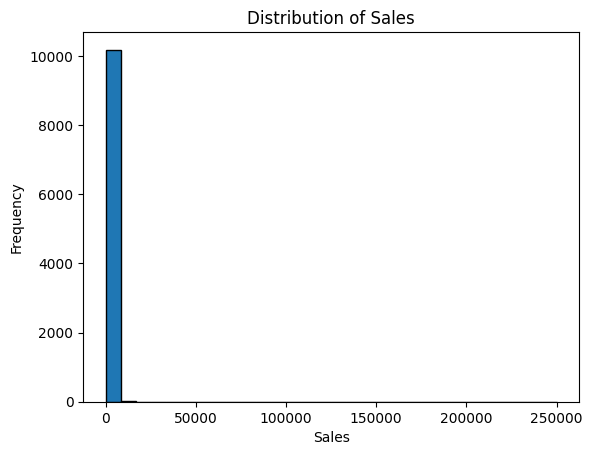

In [44]:
plt.hist(df["Sales"].dropna(), bins=30, edgecolor="black")

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

In [45]:
df.describe(include="number").T

,count,mean,std,min,25%,50%,75%,max
Row ID,10197.0,5098.053545,2942.648952,1.000,2550.00000,5099.0000,7645.000000,10194.000
Sales,10194.0,252.749867,2550.323407,0.444,17.22500,53.9300,209.500000,250000.000
Discount,10197.0,0.155579,0.206616,0.000,0.00000,0.2000,0.200000,1.250
Profit,10194.0,23.708219,547.329611,-50000.000,1.75155,8.6855,29.282175,8399.976


In [46]:
df[df["Sales"] < 0]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit


In [47]:
df.nlargest(10, "Sales")[
    ["Order ID", "Product Name", "Category", "Sales", "Profit"]
]

,Order ID,Product Name,Category,Sales,Profit
27,US-2023-162775,Staple envelope,Office Supplies,250000.000,5.3392
226,US-2023-145317,Cisco TelePresence System EX90 Videoconferenci...,Technology,22638.480,-1811.0784
5894,US-2025-118689,Canon imageCLASS 2200 Advanced Copier,Technology,17499.950,8399.9760
7255,US-2026-140151,Canon imageCLASS 2200 Advanced Copier,Technology,13999.960,6719.9808
9171,US-2026-127180,Canon imageCLASS 2200 Advanced Copier,Technology,11199.968,3919.9888
9517,US-2026-166709,Canon imageCLASS 2200 Advanced Copier,Technology,10499.970,5039.9856
6674,US-2025-117121,GBC Ibimaster 500 Manual ProClick Binding System,Office Supplies,9892.740,4946.3700
1203,US-2023-116904,Ibico EPK-21 Electric Binding System,Office Supplies,9449.950,4630.4755
4624,US-2025-107440,"3D Systems Cube Printer, 2nd Generation, Magenta",Technology,9099.930,2365.9818
4282,US-2025-158841,HP Designjet T520 Inkjet Large Format Printer ...,Technology,8749.950,2799.9840


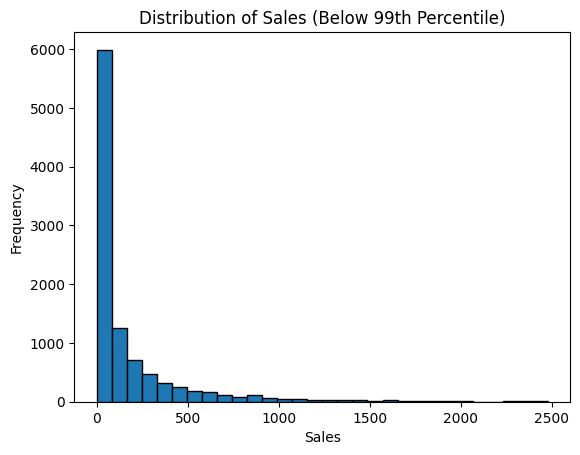

In [48]:
sales_99 = df["Sales"].quantile(0.99)

plt.hist(
    df.loc[df["Sales"] <= sales_99, "Sales"].dropna(),
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Sales (Below 99th Percentile)")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

This first histogram using the frequency and the sales numbers seems to be very right skewed, there are no visible negative values. With Sales, it is highly right skewed with one or more Really large observation but these are not instantly errors they just require more investigation. The largest sale is $250,000 with a profit of $5.34, this is a little absurd. This coudl explain the right skew with the next highest value being around 22000. 

In [49]:
## Discount

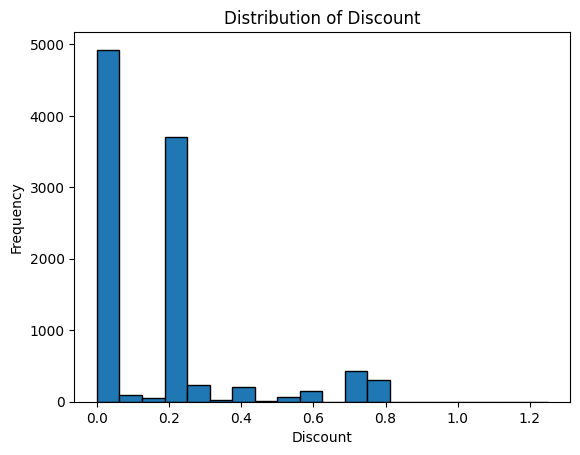

In [50]:
plt.hist(df["Discount"].dropna(), bins=20, edgecolor="black")

plt.title("Distribution of Discount")
plt.xlabel("Discount")
plt.ylabel("Frequency")
plt.show()

In [51]:
df[df["Discount"] > 0.80]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
2683,2684,US-2024-104059,6/13/24,6/15/24,Second Class,FC-14245,Frank Carlisle,Home Office,United States,Springfield,...,45503,East,OFF-AR-10000634,Office Supplies,Art,Newell 320,3.424,1,1.25,0.2996


The Discount histogram revealed an unusually high value of 1.25. Further investigation identified this value in Row ID 2684. Because the business rules specify that valid discounts must range from 0.00 to 0.80, the value of 1.25 is a confirmed data-quality error. However, the correct discount cannot be determined from the available information, so an appropriate treatment will need to be considered during the cleaning process.

In [52]:
## Profit

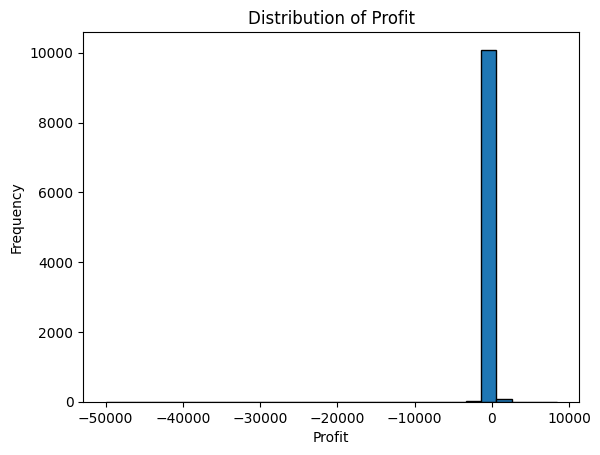

In [53]:
plt.hist(df["Profit"].dropna(), bins=30, edgecolor="black")

plt.title("Distribution of Profit")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.show()

In [54]:
df.nsmallest(10, "Profit")[
    ["Row ID", "Order ID", "Product Name", "Sales", "Quantity", "Discount", "Profit"]
]

,Row ID,Order ID,Product Name,Sales,Quantity,Discount,Profit
7147,7148,US-2026-141558,"Avery Trapezoid Ring Binder, 3"" Capacity, Blac...",12.294,1,0.7,-50000.0000
6398,6399,US-2025-108196,Cubify CubeX 3D Printer Double Head Print,4499.985,5,0.7,-6599.9780
9318,9319,US-2026-168116,Cubify CubeX 3D Printer Triple Head Print,7999.980,4,0.5,-3839.9904
821,822,US-2023-169019,GBC DocuBind P400 Electric Binding System,2177.584,8,0.8,-3701.8928
7441,7442,US-2026-134845,Lexmark MX611dhe Monochrome Laser Printer,2549.985,5,0.7,-3399.9800
9845,9846,US-2026-122714,Ibico EPK-21 Electric Binding System,1889.990,5,0.8,-2929.4845
4037,4038,US-2024-147830,Cubify CubeX 3D Printer Double Head Print,1799.994,2,0.7,-2639.9912
9557,9558,US-2026-131254,Fellowes PB500 Electric Punch Plastic Comb Bin...,1525.188,6,0.8,-2287.7820
2108,2109,US-2024-116638,Chromcraft Bull-Nose Wood Oval Conference Tabl...,4297.644,13,0.4,-1862.3124
4570,4571,US-2025-130946,GBC DocuBind P400 Electric Binding System,1088.792,4,0.8,-1850.9464


In [55]:
df.nlargest(10, "Profit")[
    ["Row ID", "Order ID", "Product Name",
     "Sales", "Quantity", "Discount", "Profit"]
]

,Row ID,Order ID,Product Name,Sales,Quantity,Discount,Profit
5894,5895,US-2025-118689,Canon imageCLASS 2200 Advanced Copier,17499.950,5,0.0,8399.9760
7255,7256,US-2026-140151,Canon imageCLASS 2200 Advanced Copier,13999.960,4,0.0,6719.9808
9517,9518,US-2026-166709,Canon imageCLASS 2200 Advanced Copier,10499.970,3,0.0,5039.9856
6674,6675,US-2025-117121,GBC Ibimaster 500 Manual ProClick Binding System,9892.740,13,0.0,4946.3700
1203,1204,US-2023-116904,Ibico EPK-21 Electric Binding System,9449.950,5,0.0,4630.4755
9171,9172,US-2026-127180,Canon imageCLASS 2200 Advanced Copier,11199.968,4,0.2,3919.9888
2242,2243,US-2024-145352,Fellowes PB500 Electric Punch Plastic Comb Bin...,6354.950,5,0.0,3177.4750
4282,4283,US-2025-158841,HP Designjet T520 Inkjet Large Format Printer ...,8749.950,5,0.0,2799.9840
5907,5908,US-2025-140158,Hewlett Packard LaserJet 3310 Copier,5399.910,9,0.0,2591.9568
6882,6883,US-2026-138289,GBC DocuBind P400 Electric Binding System,5443.960,4,0.0,2504.2216


Profit Distribution: The histogram revealed an extreme negative profit value of -$50,000. Further investigation showed that this observation corresponds to a binder with Sales of only $12.294, Quantity of 1, and a 0.70 discount. The next-largest loss in the dataset is approximately -$6,600, making the -$50,000 value unusually extreme. Although negative profits are permitted by the business rules, this observation appears suspicious and requires further investigation before determining whether it should be retained, corrected, or removed.

In [56]:
# Box Plots

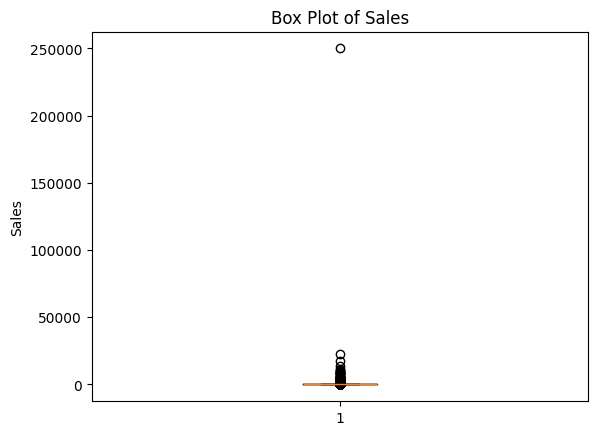

In [57]:
plt.boxplot(df["Sales"].dropna())

plt.title("Box Plot of Sales")
plt.ylabel("Sales")
plt.show()

In [58]:
Q1 = df["Sales"].quantile(0.25)
Q3 = df["Sales"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 17.224999999999998
Q3: 209.5
IQR: 192.275
Lower Bound: -271.1875
Upper Bound: 497.9125


In [ ]:
sales_outliers = df[
    (df["Sales"] < lower_bound) |
    (df["Sales"] > upper_bound)
]
print("Number of potential outliers:", len(sales_outliers))

Number of potential outliers: 1184


In [60]:
sales_outliers.sort_values("Sales", ascending=False)[
    ["Row ID", "Product Name", "Sales", "Profit"]
].head(10)

,Row ID,Product Name,Sales,Profit
27,28,Staple envelope,250000.000,5.3392
226,227,Cisco TelePresence System EX90 Videoconferenci...,22638.480,-1811.0784
5894,5895,Canon imageCLASS 2200 Advanced Copier,17499.950,8399.9760
7255,7256,Canon imageCLASS 2200 Advanced Copier,13999.960,6719.9808
9171,9172,Canon imageCLASS 2200 Advanced Copier,11199.968,3919.9888
9517,9518,Canon imageCLASS 2200 Advanced Copier,10499.970,5039.9856
6674,6675,GBC Ibimaster 500 Manual ProClick Binding System,9892.740,4946.3700
1203,1204,Ibico EPK-21 Electric Binding System,9449.950,4630.4755
4624,4625,"3D Systems Cube Printer, 2nd Generation, Magenta",9099.930,2365.9818
4282,4283,HP Designjet T520 Inkjet Large Format Printer ...,8749.950,2799.9840


NOTES: The amount of outliers is unusual but we need more information before we can remove anything, if anythign these outliers are statistically unusual rather than an error that needs to be taken care of. 

In [61]:
## Discount

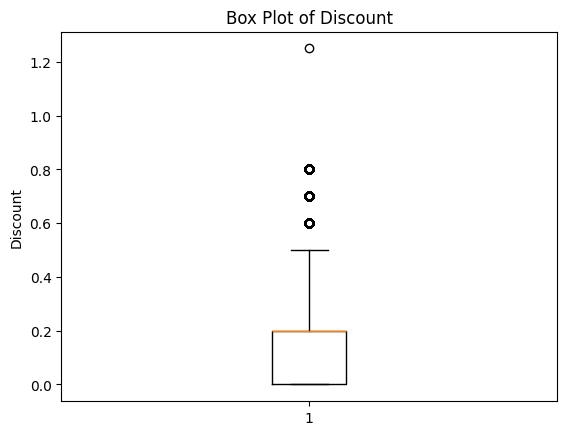

In [63]:
plt.boxplot(df["Discount"].dropna())

plt.title("Box Plot of Discount")
plt.ylabel("Discount")
plt.show()

In [65]:
Q1 = df["Discount"].quantile(0.25)
Q3 = df["Discount"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 0.0
Q3: 0.2
IQR: 0.2
Lower Bound: -0.30000000000000004
Upper Bound: 0.5


In [66]:
discount_outliers = df[
    (df["Discount"] < lower_bound) |
    (df["Discount"] > upper_bound)
]

print("Number of potential outliers:", len(discount_outliers))

Number of potential outliers: 876


In [72]:
# Statistical outliers according to IQR
print("IQR outliers:", len(discount_outliers))

# Actual business-rule violations
invalid_discounts = df[
    (df["Discount"] < 0) |
    (df["Discount"] > 0.80)
]

print("Invalid discounts:", len(invalid_discounts))

IQR outliers: 876
Invalid discounts: 1


Notes: Again a good amount of outliers in this, however I do not think that there are enough to really worry about within this and we will probably clean a lot of them up in the cleaning stage. According to the business rules, a data quality error would be greater than .8 or less than 0.00. Even though there are 876 outliers there is actually only 1 error in that group. This now confirms that this is an error.

In [67]:
## Profit

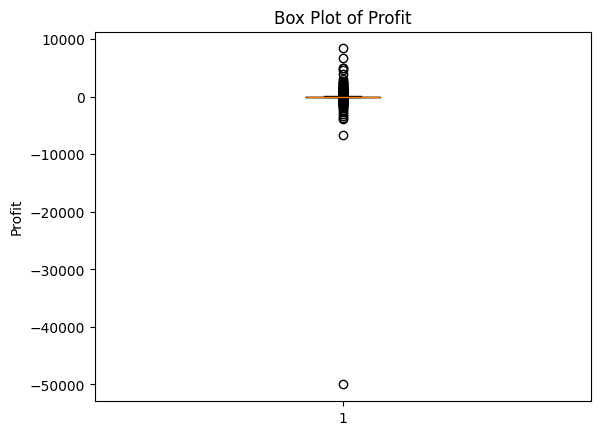

In [68]:
# Box plot for Profit
plt.boxplot(df["Profit"].dropna())

plt.title("Box Plot of Profit")
plt.ylabel("Profit")
plt.show()

In [69]:
Q1 = df["Profit"].quantile(0.25)
Q3 = df["Profit"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 1.75155
Q3: 29.282175
IQR: 27.530625
Lower Bound: -39.5443875
Upper Bound: 70.5781125


In [70]:
profit_outliers = df[
    (df["Profit"] < lower_bound) |
    (df["Profit"] > upper_bound)
]

print("Number of potential outliers:", len(profit_outliers))

Number of potential outliers: 1915


In [71]:
profit_outliers.sort_values("Profit")[
    ["Row ID", "Product Name", "Sales", "Discount", "Profit"]
].head(10)

,Row ID,Product Name,Sales,Discount,Profit
7147,7148,"Avery Trapezoid Ring Binder, 3"" Capacity, Blac...",12.294,0.7,-50000.0000
6398,6399,Cubify CubeX 3D Printer Double Head Print,4499.985,0.7,-6599.9780
9318,9319,Cubify CubeX 3D Printer Triple Head Print,7999.980,0.5,-3839.9904
821,822,GBC DocuBind P400 Electric Binding System,2177.584,0.8,-3701.8928
7441,7442,Lexmark MX611dhe Monochrome Laser Printer,2549.985,0.7,-3399.9800
9845,9846,Ibico EPK-21 Electric Binding System,1889.990,0.8,-2929.4845
4037,4038,Cubify CubeX 3D Printer Double Head Print,1799.994,0.7,-2639.9912
9557,9558,Fellowes PB500 Electric Punch Plastic Comb Bin...,1525.188,0.8,-2287.7820
2108,2109,Chromcraft Bull-Nose Wood Oval Conference Tabl...,4297.644,0.4,-1862.3124
4570,4571,GBC DocuBind P400 Electric Binding System,1088.792,0.8,-1850.9464


Notes: The Business rules do allow for us to have a negative profit margin, therefore they should not be treated immediately as errors within the data. The negative $50000 profit is something that does continue to require information to be gathered about it so that we can make a decision about it. 

In [ ]:
## Quantity Type

One of the business rules states that, Quantity should be a positve whole number, whereas this table csv file has it as an object type so we are now going to do some digging into why this is happening and what we need to do to fix it

In [73]:
df["Quantity"].dtype

dtype('O')

In [74]:
df["Quantity"].unique()

array(['2', '3', '9', '4', '1', '7', '6', '5', '10', '8', '13', '14',
       '12', '11', '-2', 'Five'], dtype=object)

It would seeem that there are 2 invalid fields making this column an object column rather than an integer, that would be the -2 and five. 

In [75]:
df["Quantity"].value_counts(dropna=False)

Quantity
2       2439
3       2436
5       1269
4       1213
1        933
7        617
6        585
8        269
9        259
10        61
11        34
14        30
13        27
12        23
-2         1
Five       1
Name: count, dtype: int64

There is only 1 Value of -2 and 1 value of five 

In [76]:
quantity_numeric = pd.to_numeric(df["Quantity"], errors="coerce")

In [77]:
df.loc[
    quantity_numeric.isna() & df["Quantity"].notna(),
    ["Row ID", "Quantity"]
]

,Row ID,Quantity
5468,5469,Five


In [78]:
df["Quantity"].isna().sum()

np.int64(0)

In [79]:
quantity_numeric.isna().sum()

np.int64(1)

In [80]:
df.loc[quantity_numeric <= 0]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
4016,4017,US-2024-157770,12/13/24,12/15/24,First Class,RD-19585,Rob Dowd,Consumer,United States,Temecula,...,92592,West,TEC-AC-10001552,Technology,Accessories,Logitech K350 2.4Ghz Wireless Keyboard,248.85,-2,0.0,27.3735


There is also a negative quantity in this situation where it is negative 2 quantity

In [81]:
df.loc[
    quantity_numeric.notna() &
    (quantity_numeric % 1 != 0)
]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit


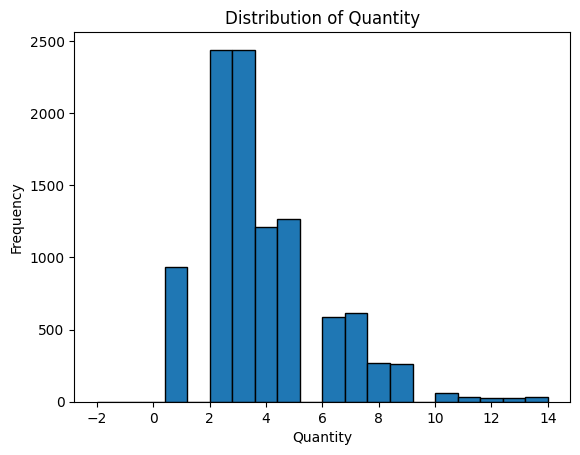

In [82]:
plt.hist(quantity_numeric.dropna(), bins=20, edgecolor="black")

plt.title("Distribution of Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

What we did was we made a copy essentially of the quantity column to see what it would be like if everything was forced to be numeric, this allowed us to see the values that are not following the business rules as well as what we can do to fix them in the next part, cleaning. These observations will require cleaning before we can go further with the analysis to make any business decisions for the comapny.

In [84]:
df[df["Quantity"].isin(["-2", "Five"])]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
4016,4017,US-2024-157770,12/13/24,12/15/24,First Class,RD-19585,Rob Dowd,Consumer,United States,Temecula,...,92592,West,TEC-AC-10001552,Technology,Accessories,Logitech K350 2.4Ghz Wireless Keyboard,248.85,-2,0.0,27.3735
5468,5469,US-2025-114601,8/26/25,9/2/25,Standard Class,AA-10480,Andrew Allen,Consumer,United States,Detroit,...,48234,Central,OFF-PA-10000605,Office Supplies,Paper,Xerox 1950,11.56,Five,0.0,5.6644


In [85]:
quantity_numeric = pd.to_numeric(
    df["Quantity"].replace("Five", "5"),
    errors="coerce"
)

Now we are using quantity numeric, like earlier to test run the idea of changing five to 5 and seeing what happens with the distribution and how it affects the data before changing the dataframe

In [86]:
df[quantity_numeric.isna()]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit


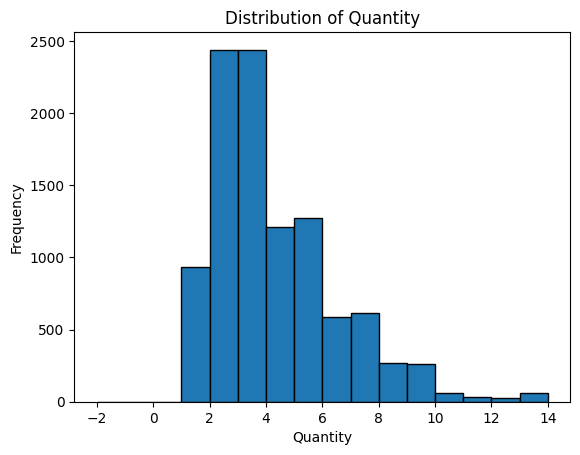

In [87]:
plt.hist(quantity_numeric.dropna(), bins=16, edgecolor="black")

plt.title("Distribution of Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

Check DAtes 

In [88]:
df[["Order Date", "Ship Date"]].dtypes

Order Date    object
Ship Date     object
dtype: object

In [89]:
order_date = pd.to_datetime(df["Order Date"], errors="coerce")
ship_date = pd.to_datetime(df["Ship Date"], errors="coerce")

C:\Users\dvdsl\AppData\Local\Temp\ipykernel_14128\3938631206.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  order_date = pd.to_datetime(df["Order Date"], errors="coerce")
C:\Users\dvdsl\AppData\Local\Temp\ipykernel_14128\3938631206.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ship_date = pd.to_datetime(df["Ship Date"], errors="coerce")


There is an error somewhere in the dates columns, as it would not instantly convert from object to date time

In [90]:
df[["Order Date", "Ship Date"]].head(20)

,Order Date,Ship Date
0,1/3/23,1/7/23
1,1/4/23,1/8/23
2,1/4/23,1/8/23
3,1/4/23,1/8/23
4,1/5/23,1/12/23
5,1/6/23,1/10/23
6,1/6/23,1/10/23
7,1/6/23,1/7/23
8,1/6/23,1/10/23
9,1/6/23,1/10/23


In [91]:
print(df["Order Date"].unique()[:30])
print(df["Ship Date"].unique()[:30])

['1/3/23' '1/4/23' '1/5/23' '1/6/23' '1/7/23' '1/9/23' '1/10/23' '1/11/23'
 '1/13/23' '1/14/23' '1/15/23' '1/16/23' '1/18/23' '1/19/23' '1/20/23'
 '1/21/23' '1/23/23' '1/26/23' '1/27/23' '1/28/23' '1/30/23' '1/31/23'
 '2/1/23' '2/2/23' '2/3/23' '2/4/23' '2/6/23' '2/7/23' '2/8/23' '2/11/23']
['1/7/23' '1/8/23' '1/12/23' '1/10/23' '1/13/23' '1/15/23' '1/14/23'
 '1/18/23' '1/16/23' '1/17/23' '1/21/23' '1/20/23' '1/26/23' '1/25/23'
 '1/23/23' '1/24/23' '1/27/23' '1/28/23' '1/29/23' '1/31/23' '2/2/23'
 '2/3/23' '2/4/23' '2/9/23' '2/6/23' '2/8/23' '2/10/23' '2/12/23'
 '2/15/23' '2/18/23']


In [92]:
order_date = pd.to_datetime(
    df["Order Date"],
    format="mixed",
    errors="coerce"
)

ship_date = pd.to_datetime(
    df["Ship Date"],
    format="mixed",
    errors="coerce"
)

In [94]:
print("Invalid Order Dates:", order_date.isna().sum())
print("Invalid Ship Dates:", ship_date.isna().sum())

Invalid Order Dates: 0
Invalid Ship Dates: 0


In [95]:
date_issues = df[order_date > ship_date]

print("Order Date after Ship Date:", len(date_issues))

date_issues[
    ["Row ID", "Order ID", "Order Date", "Ship Date"]
]

Order Date after Ship Date: 0


,Row ID,Order ID,Order Date,Ship Date


It would seem that the data only needed a bit of coercion to mix with the date time format. Both Order Date and Ship Date were successfully parsed using mixed date formats, with no values failing conversion. A chronological consistency check was then used to identify any records where Order Date occurred after Ship Date.

## Part 3

In [97]:
clean = df.copy()

In [98]:
print("Original:", df.shape)
print("Cleaned:", clean.shape)

Original: (10197, 21)
Cleaned: (10197, 21)


In [99]:
clean["Category"] = (
    clean["Category"]
    .str.strip()
    .str.title()
)

In [100]:
clean["Category"].value_counts(dropna=False)
clean["Category"].unique()
clean["Category"].nunique()

3

This is fixing the whitespace in Category making it so that there are only 3 values instead of 6

In [101]:
# Convert the clear text value "Five" to "5"
clean["Quantity"] = clean["Quantity"].replace("Five", "5")

# Convert Quantity from object to numeric
clean["Quantity"] = pd.to_numeric(
    clean["Quantity"],
    errors="coerce"
)

In [102]:
print(clean["Quantity"].dtype)
print(clean["Quantity"].unique())

int64
[ 2  3  9  4  1  7  6  5 10  8 13 14 12 11 -2]


Have not yet figured what to do with the -2 but this is now in int64 type as the business rules say and we will figure out what we need to do with the -2 record in the future

In [103]:
clean[clean["Quantity"] <= 0]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
4016,4017,US-2024-157770,12/13/24,12/15/24,First Class,RD-19585,Rob Dowd,Consumer,United States,Temecula,...,92592,West,TEC-AC-10001552,Technology,Accessories,Logitech K350 2.4Ghz Wireless Keyboard,248.85,-2,0.0,27.3735


There is only one record that has this negative 2 quantity, we are going to change it to an unknown value quantity because we do not know what it should have been in the first place. 

In [104]:
clean.loc[clean["Quantity"] <= 0, "Quantity"] = pd.NA

In [106]:
clean[clean["Quantity"] <= 0]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit


This confirms that the negative number was taken care of, making it comply with the business rules provided

### Handle Discount

In [107]:
clean.loc[
    (clean["Discount"] < 0) | (clean["Discount"] > 0.80),
    "Discount"
] = pd.NA

Rather than randomly changing the discount number to decimal that complies with the business rules, we are goign to change it to an unknown value. 

In [108]:
clean[
    (clean["Discount"] < 0) |
    (clean["Discount"] > 0.80)
]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit


This confirms that the error has been resolved in this manner

### Unusually High Sales 

In [109]:
clean.nlargest(1, "Sales")

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
27,28,US-2023-162775,1/13/23,1/15/23,Second Class,CS-12250,Chris Selesnick,Corporate,United States,Bossier City,...,71111,South,OFF-EN-10001990,Office Supplies,Envelopes,Staple envelope,250000.0,2.0,0.0,5.3392


Decision is to not do anythign with this as it is permitted to have unusually high values of sales, although extreme and suspicious, and potentially unhelpful, it does not violate the Sales Business rule. And there is not really much in information to deal with a replacement number

### Profit

Same approach, we are going to retain it for now, there is strong reason to be suspicious due to the nature that sales is 12.29 but it does not explicitly violate the business rule so it will remain as it is.

### Missing Values 

In [110]:
print("Original missing values:")
print(df.isna().sum()[df.isna().sum() > 0])

print("\nCleaned missing values:")
print(clean.isna().sum()[clean.isna().sum() > 0])

Original missing values:
Customer Name    3
Sales            3
Profit           3
dtype: int64

Cleaned missing values:
Customer Name    3
Sales            3
Quantity         1
Discount         1
Profit           3
dtype: int64


There is now 1 in Quantity, and Discount because there is an unknown value in each from the work that we have already done in cleaning


Going to now inspect the missing values 

In [111]:
missing_original = df[
    df["Customer Name"].isna() |
    df["Sales"].isna() |
    df["Profit"].isna()
]

missing_original[
    [
        "Row ID",
        "Order ID",
        "Customer ID",
        "Customer Name",
        "Product Name",
        "Sales",
        "Quantity",
        "Discount",
        "Profit"
    ]
]

,Row ID,Order ID,Customer ID,Customer Name,Product Name,Sales,Quantity,Discount,Profit
625,626,US-2023-144414,GH-14425,NaN,GBC DocuBind P400 Electric Binding System,3266.376,3,0.2,1061.5722
857,858,US-2023-134215,ML-17395,Marina Lichtenstein,Maxell 4.7GB DVD-R,NaN,9,0.0,104.7222
1428,1429,US-2023-145387,AM-10705,Anne McFarland,"RSVP Cards & Envelopes, Blank White, 8-1/2"" X ...",NaN,2,0.0,4.7752
1764,1765,US-2023-131527,TB-21280,Toby Braunhardt,"BlueLounge Milo Smartphone Stand, White/Metallic",95.968,4,0.2,NaN
4367,4368,US-2025-112123,BH-11710,Brosina Hoffman,GBC ProClick Punch Binding System,447.860,7,0.0,NaN
4385,4386,US-2025-110898,LC-16870,Lena Cacioppo,Eldon Cleatmat Plus Chair Mats for High Pile C...,NaN,5,0.6,-194.8240
6211,6212,US-2025-124506,BB-11545,NaN,Global Chrome Stack Chair,47.992,2,0.3,-2.0568
6672,6673,US-2025-155446,TN-21040,Tanja Norvell,Imation USB 2.0 Swivel Flash Drive USB flash d...,21.210,7,0.0,NaN
8785,8786,US-2026-153822,AB-10105,NaN,Akro Stacking Bins,12.624,2,0.2,-2.5248


In [112]:
missing_customer_ids = df.loc[
    df["Customer Name"].isna(),
    "Customer ID"
]

df[df["Customer ID"].isin(missing_customer_ids)][
    ["Customer ID", "Customer Name"]
].drop_duplicates().sort_values("Customer ID")

,Customer ID,Customer Name
1921,AB-10105,Adrian Barton
8785,AB-10105,NaN
2644,BB-11545,Brenda Bowman
6211,BB-11545,NaN
624,GH-14425,Gary Hwang
625,GH-14425,NaN


Shows that prior customers returned to buy again so we can fill their names in on those 23 records of the same customer name matchign with the customer ID

In [113]:
customer_map = (
    clean.dropna(subset=["Customer Name"])
    .drop_duplicates("Customer ID")
    .set_index("Customer ID")["Customer Name"]
)

clean["Customer Name"] = clean["Customer Name"].fillna(
    clean["Customer ID"].map(customer_map)
)

In [114]:
print("Missing Customer Names:", clean["Customer Name"].isna().sum())

clean.loc[
    clean["Customer ID"].isin(["AB-10105", "BB-11545", "GH-14425"]),
    ["Customer ID", "Customer Name"]
].drop_duplicates()

Missing Customer Names: 0


,Customer ID,Customer Name
624,GH-14425,Gary Hwang
1921,AB-10105,Adrian Barton
2644,BB-11545,Brenda Bowman


Through this process we went from missing the customer names to matching the customer ID and moving the matching names from the ID into the empty spots in the dataset

### Sales and Profit Missing Values

It would not be advisable to input average or median financial data as that would be artificial, and could affect the analysis in a negative way. Thus we are retaining the missing values as missing values because we could not determine a correct transaction level number with the given data

In [115]:
clean.isna().sum()[clean.isna().sum() > 0]

Sales       3
Quantity    1
Discount    1
Profit      3
dtype: int64

### Duplicates

In [116]:
print("Exact duplicate rows:", df.duplicated().sum())

Exact duplicate rows: 3


In [117]:
duplicates = df[df.duplicated(keep=False)]

duplicates.sort_values(
    ["Order ID", "Product Name"]
)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
6606,6607,US-2025-162187,12/11/25,12/11/25,Same Day,NS-18640,Noel Staavos,Corporate,United States,Columbus,...,43229,East,FUR-TA-10003008,Furniture,Tables,"Lesro Round Back Collection Coffee Table, End ...",328.590,3,0.4,-147.8655
10195,6607,US-2025-162187,12/11/25,12/11/25,Same Day,NS-18640,Noel Staavos,Corporate,United States,Columbus,...,43229,East,FUR-TA-10003008,Furniture,Tables,"Lesro Round Back Collection Coffee Table, End ...",328.590,3,0.4,-147.8655
6870,6871,US-2026-138779,1/14/26,1/15/26,First Class,RB-19570,Rob Beeghly,Consumer,United States,Jacksonville,...,28540,South,TEC-PH-10003655,Technology,Phones,Sannysis Cute Owl Design Soft Skin Case Cover ...,7.920,5,0.2,0.6930
10196,6871,US-2026-138779,1/14/26,1/15/26,First Class,RB-19570,Rob Beeghly,Consumer,United States,Jacksonville,...,28540,South,TEC-PH-10003655,Technology,Phones,Sannysis Cute Owl Design Soft Skin Case Cover ...,7.920,5,0.2,0.6930
7458,7459,US-2026-152366,4/21/26,4/25/26,Second Class,SJ-20500,Shirley Jackson,Consumer,United States,Houston,...,77036,Central,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",97.264,4,0.8,-243.1600
10194,7459,US-2026-152366,4/21/26,4/25/26,Second Class,SJ-20500,Shirley Jackson,Consumer,United States,Houston,...,77036,Central,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",97.264,4,0.8,-243.1600


In [118]:
columns_to_check = [
    col for col in df.columns
    if col != "Row ID"
]

print(
    "Duplicates excluding Row ID:",
    df.duplicated(
        subset=columns_to_check
    ).sum()
)

Duplicates excluding Row ID: 5


In [119]:
duplicate_records = df[
    df.duplicated(
        subset=columns_to_check,
        keep=False
    )
]

duplicate_records.sort_values(
    ["Order ID", "Product Name"]
)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
1698,1699,CA-2023-153623,11/24/23,12/5/23,Standard Class,JP-11135,James Peterman,Corporate,Canada,St. John's,...,A0A,East,FUR-FU-10002501,Furniture,Furnishings,Nu-Dell Executive Frame,99.120,8,0.0,35.4144
1699,1700,CA-2023-153623,11/24/23,12/5/23,Standard Class,JP-11135,James Peterman,Corporate,Canada,St. John's,...,A0A,East,FUR-FU-10002501,Furniture,Furnishings,Nu-Dell Executive Frame,99.120,8,0.0,35.4144
390,391,US-2023-150119,4/23/23,4/27/23,Standard Class,LB-16795,Laurel Beltran,Home Office,United States,Columbus,...,43229,East,FUR-CH-10002965,Furniture,Chairs,Global Leather Highback Executive Chair with P...,281.372,2,0.3,-12.0588
391,392,US-2023-150119,4/23/23,4/27/23,Standard Class,LB-16795,Laurel Beltran,Home Office,United States,Columbus,...,43229,East,FUR-CH-10002965,Furniture,Chairs,Global Leather Highback Executive Chair with P...,281.372,2,0.3,-12.0588
6606,6607,US-2025-162187,12/11/25,12/11/25,Same Day,NS-18640,Noel Staavos,Corporate,United States,Columbus,...,43229,East,FUR-TA-10003008,Furniture,Tables,"Lesro Round Back Collection Coffee Table, End ...",328.590,3,0.4,-147.8655
10195,6607,US-2025-162187,12/11/25,12/11/25,Same Day,NS-18640,Noel Staavos,Corporate,United States,Columbus,...,43229,East,FUR-TA-10003008,Furniture,Tables,"Lesro Round Back Collection Coffee Table, End ...",328.590,3,0.4,-147.8655
6870,6871,US-2026-138779,1/14/26,1/15/26,First Class,RB-19570,Rob Beeghly,Consumer,United States,Jacksonville,...,28540,South,TEC-PH-10003655,Technology,Phones,Sannysis Cute Owl Design Soft Skin Case Cover ...,7.920,5,0.2,0.6930
10196,6871,US-2026-138779,1/14/26,1/15/26,First Class,RB-19570,Rob Beeghly,Consumer,United States,Jacksonville,...,28540,South,TEC-PH-10003655,Technology,Phones,Sannysis Cute Owl Design Soft Skin Case Cover ...,7.920,5,0.2,0.6930
7458,7459,US-2026-152366,4/21/26,4/25/26,Second Class,SJ-20500,Shirley Jackson,Consumer,United States,Houston,...,77036,Central,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",97.264,4,0.8,-243.1600
10194,7459,US-2026-152366,4/21/26,4/25/26,Second Class,SJ-20500,Shirley Jackson,Consumer,United States,Houston,...,77036,Central,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",97.264,4,0.8,-243.1600


This is checking which are the duplicate records or not. Something to note, there is the exact same data on two rows next to each other, Row ID 1699 then 1700 being the same, so they would have gone unexposed had we not done the previous step of digging to exclude the Row ID from the duplicate count

In [120]:
order_product_duplicates = df[
    df.duplicated(
        subset=["Order ID", "Product ID"],
        keep=False
    )
]

print(
    "Rows with repeated Order ID + Product ID:",
    len(order_product_duplicates)
)

order_product_duplicates.sort_values(
    ["Order ID", "Product ID"]
)[
    [
        "Row ID",
        "Order ID",
        "Product ID",
        "Product Name",
        "Sales",
        "Quantity",
        "Discount",
        "Profit"
    ]
]

Rows with repeated Order ID + Product ID: 28


,Row ID,Order ID,Product ID,Product Name,Sales,Quantity,Discount,Profit
2017,2018,CA-2023-123625,FUR-FU-10004093,Hand-Finished Solid Wood Document Frame,101.120,8,0.0,37.4144
2019,2020,CA-2023-123625,FUR-FU-10004093,Hand-Finished Solid Wood Document Frame,68.460,2,0.0,20.5380
2020,2021,CA-2023-123625,OFF-FA-10000089,Acco Glide Clips,68.460,2,0.0,20.5380
2022,2023,CA-2023-123625,OFF-FA-10000089,Acco Glide Clips,19.600,5,0.0,9.6040
1698,1699,CA-2023-153623,FUR-FU-10002501,Nu-Dell Executive Frame,99.120,8,0.0,35.4144
1699,1700,CA-2023-153623,FUR-FU-10002501,Nu-Dell Executive Frame,99.120,8,0.0,35.4144
390,391,US-2023-150119,FUR-CH-10002965,Global Leather Highback Executive Chair with P...,281.372,2,0.3,-12.0588
391,392,US-2023-150119,FUR-CH-10002965,Global Leather Highback Executive Chair with P...,281.372,2,0.3,-12.0588
2879,2880,US-2024-103135,OFF-BI-10000069,"GBC Prepunched Paper, 19-Hole, for Binding Sys...",135.090,9,0.0,62.1414
2880,2881,US-2024-103135,OFF-BI-10000069,"GBC Prepunched Paper, 19-Hole, for Binding Sys...",90.060,6,0.0,41.4276


The intent behind this is to see if there are more duplicates that ignore more than just the Row ID 

In [121]:
columns_to_check = [
    col for col in clean.columns
    if col != "Row ID"
]

before = len(clean)

clean = clean.drop_duplicates(
    subset=columns_to_check,
    keep="first"
)

after = len(clean)

print("Rows before:", before)
print("Rows after:", after)
print("Rows removed:", before - after)

Rows before: 10197
Rows after: 10192
Rows removed: 5


In [122]:
print(
    "Remaining duplicates:",
    clean.duplicated(
        subset=columns_to_check
    ).sum()
)

Remaining duplicates: 0


Originally, it was thought that there was only 3 duplicate rows but when you ignore the Row ID there are 5 duplicates that are getting removed bringing the total from 10197 to 10192. This follows the Business rule that duplicates get investigated before getting removed

### Standardize Date Columns

In [123]:
clean["Order Date"] = pd.to_datetime(
    clean["Order Date"],
    format="mixed"
)

clean["Ship Date"] = pd.to_datetime(
    clean["Ship Date"],
    format="mixed"
)

In [124]:
print(clean["Order Date"].dtype)
print(clean["Ship Date"].dtype)

print(
    "Order Date after Ship Date:",
    (clean["Order Date"] > clean["Ship Date"]).sum()
)

datetime64[ns]
datetime64[ns]
Order Date after Ship Date: 0


The Date columns, being the Order Date and the Ship Date are in the date time format. After cleaning that it makes sure that the dates follow a logical thought that the order date is always before the ship date. 

## Part 4: Validate the Cleaned Dataset

In [125]:
print("Original shape:", df.shape)
print("Cleaned shape:", clean.shape)

Original shape: (10197, 21)
Cleaned shape: (10192, 21)


In [126]:
print("Original missing values:")
print(df.isna().sum()[df.isna().sum() > 0])

print("\nCleaned missing values:")
print(clean.isna().sum()[clean.isna().sum() > 0])

Original missing values:
Customer Name    3
Sales            3
Profit           3
dtype: int64

Cleaned missing values:
Sales       3
Quantity    1
Discount    1
Profit      3
dtype: int64


In [127]:
print(clean["Category"].unique())
print(clean["Category"].value_counts())

['Office Supplies' 'Furniture' 'Technology']
Category
Office Supplies    6128
Furniture          2199
Technology         1865
Name: count, dtype: int64


In [128]:
print("Quantity dtype:", clean["Quantity"].dtype)

print(
    "Invalid quantities:",
    ((clean["Quantity"] <= 0) & clean["Quantity"].notna()).sum()
)

Quantity dtype: float64
Invalid quantities: 0


In [129]:
print(
    "Invalid discounts:",
    (
        ((clean["Discount"] < 0) | (clean["Discount"] > 0.80))
        & clean["Discount"].notna()
    ).sum()
)

Invalid discounts: 0


In [130]:
columns_to_check = [
    col for col in clean.columns
    if col != "Row ID"
]

print(
    "Remaining duplicates:",
    clean.duplicated(
        subset=columns_to_check
    ).sum()
)

Remaining duplicates: 0


In [131]:
print("Order Date dtype:", clean["Order Date"].dtype)
print("Ship Date dtype:", clean["Ship Date"].dtype)

print(
    "Order Date after Ship Date:",
    (clean["Order Date"] > clean["Ship Date"]).sum()
)

Order Date dtype: datetime64[ns]
Ship Date dtype: datetime64[ns]
Order Date after Ship Date: 0


After cleaning, the dataset was re-evaluated to verify that the intended corrections were successful. Category values were standardized to the three valid business categories, Quantity was converted to a numeric datatype, invalid Quantity and Discount values were no longer present as valid observations, duplicate records were removed, and missing Customer Names were recovered using Customer ID relationships. Date fields were converted to datetime and checked for chronological consistency. Extreme Sales and Profit values remained in the dataset because they were suspicious but could not be confirmed as errors. Remaining missing financial values were also retained because no defensible replacement values were available.

In [132]:
clean[
    ["Sales", "Quantity", "Discount", "Profit"]
].describe()

,Sales,Quantity,Discount,Profit
count,10189.000000,10191.000000,10191.000000,10189.000000
mean,252.793982,3.791777,0.155381,23.755870
std,2550.946947,2.228114,0.206268,547.454702
min,0.444000,1.000000,0.000000,-50000.000000
25%,17.220000,2.000000,0.000000,1.760800
50%,53.900000,3.000000,0.200000,8.690000
75%,209.500000,5.000000,0.200000,29.285700
max,250000.000000,14.000000,0.800000,8399.976000


## Part 5: Evaluate the Impact of Data Quality Through Visualization

### Sales by Category

In [133]:
original_sales_category = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

clean_sales_category = (
    clean.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print("Original:")
print(original_sales_category)

print("\nCleaned:")
print(clean_sales_category)

Original:
Category
Office Supplies    981682.2680
Technology         838430.9290
Furniture          754194.9593
Technology           1214.8500
Furniture             722.3520
office supplies       286.7900
Name: Sales, dtype: float64

Cleaned:
Category
Office Supplies    981871.7940
Technology         839637.8590
Furniture          754208.2293
Name: Sales, dtype: float64


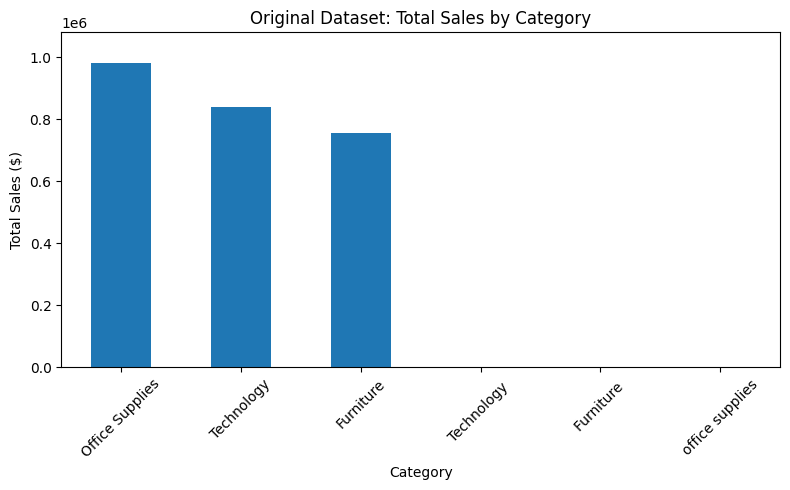

In [134]:
max_sales = max(
    original_sales_category.max(),
    clean_sales_category.max()
)

plt.figure(figsize=(8, 5))
original_sales_category.plot(kind="bar")
plt.title("Original Dataset: Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales ($)")
plt.ylim(0, max_sales * 1.10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

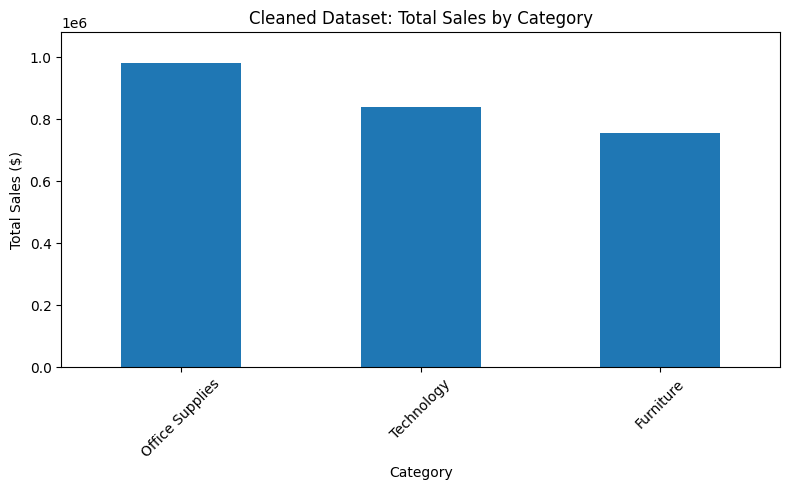

In [135]:
plt.figure(figsize=(8, 5))
clean_sales_category.plot(kind="bar")
plt.title("Cleaned Dataset: Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales ($)")
plt.ylim(0, max_sales * 1.10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Explanation: A bar chart was selected because it is appropriate for a visualization that is comparing a numerical and categorical variable. The same vertical scale is used for both to show the differences when there are 6 columns instead of 3.

### Profit by State/Province

### Export as CSV

clean.to_csv("M3_HW3_Dataset_Cleaned.csv", index=False)

print("Cleaned dataset exported successfully.")